
<!-- # Chương 1: Đánh giá Toàn diện Thuật toán FP-Growth
Dataset: `chess.dat`

Notebook này được chia thành 3 phần kiểm thử độc lập:
1. **Correctness (Tính đúng đắn):** `eval_correctness()` và `vis_correctness()`
2. **Performance (Hiệu năng):** `eval_performance()` và `vis_performance()`
3. **Scalability (Khả năng mở rộng):** `eval_scalability()` và `vis_scalability()` -->

# Evaluate

## Tải Thư viện & Gói phụ thuộc 

In [1]:
import Pkg
deps = Pkg.project().dependencies
for pkg in ["DataFrames", "CSV", "Plots"]
    if !haskey(deps, pkg)
        Pkg.add(pkg)
    end
end

using CSV
using DataFrames
using Random
using Plots
using Plots.PlotMeasures
using ProgressMeter
using Statistics
gr()

include("../src/FPGrowth.jl")
using .FPGrowth
include("../src/logger.jl")
include("../src/utils.jl")
using .Utils
logger = Logger()

success(logger, "Dependencies loaded")


[success] Dependencies loaded


## Tải hàm chức năng

In [2]:
include("../src/eval.jl")
using .Utils
success(logger, "Helper loaded")


[success] Helper loaded


## Unit Testing 
Kiểm thử tự động trên 5 CSDL thử nghiệm (Toy datasets) nhằm tái tạo đúng kết quả, đối chiếu với SPMF theo yêu cầu đồ án.
### Giới thiệu các tập dữ liệu kiểm thử (Toy Datasets)

Để đảm bảo tính đúng đắn của thuật toán FP-Growth trước khi chạy trên dữ liệu lớn, chúng ta sử dụng 5 tập dữ liệu nhỏ (Toy Datasets) với các kịch bản khác nhau. Dưới đây là mô tả chi tiết:

| Tập dữ liệu | Số giao dịch | Nội dung | Mục tiêu kiểm thử |
| :--- | :--- | :--- | :--- |
| **test1.txt** | 7 | {1,2,3,4,5}, {1,2,3,4,5}, {1,2,3,4}, {1,2,3}, {1,2,3}, {1,2}, {1} | Kiểm tra khả năng xử lý các itemset lồng nhau và giảm dần độ phổ biến. |
| **test2.txt** | 6 | {1,2,4,5}, {2,3,5}, {1,2,4,5}, {1,2,3,5}, {1,2,3,4,5}, {2,3,4} | Kiểm tra dữ liệu có mật độ trung bình với các item xuất hiện rải rác. |
| **test3.txt** | 7 | {1,2,3,4}, {2,3,4}, {2,3}, {1,2,4}, {1,2,3,4}, {2,4}, {1,3,4} | Kiểm tra các tổ hợp phổ biến của một nhóm item cụ thể {2, 3, 4}. |
| **test4.txt** | 4 | {2,3,5}, {1,2,3,5}, {2,5}, {1,2,3,5} | Kiểm tra trường hợp tập dữ liệu cực nhỏ (Edge case). |
| **test5.txt** | 5 | {1,2}, {2,3}, {3,4}, {4,5}, {1,5} | Kiểm tra dữ liệu dạng chuỗi (Chain), nơi mỗi item có liên kết hạn chế. |

> **Lưu ý**: Những tập dữ liệu trên sẽ được đối chiếu kết quả trực tiếp với thư viện SPMF để xác nhận tính chính xác của mã nguồn Julia.


### Mô tả các tập dữ liệu theo định dạng SPMF

Dạng input của SPMF thường là:

* mỗi transaction một dòng
* các item cách nhau bằng khoảng trắng
* item thường là số nguyên (`1 2 3`) hoặc string đơn giản
* không dùng `{}`, `<>`, dấu `,`

Do đó, nhằm thực hiện evaluate một cách chính xác nên nhóm thực hiện integer encoding đối với 2 tập dữ liệu `test1.txt` và `test2.txt`
#### `test1.txt`:
##### **Dữ liệu ban đầu**
```txt
T1: {A, B, D, E}
T2: {B, C, E}
T3: {A, B, D, E}
T4: {A, B, C, E}
T5: {A, B, C, D, E}
T6: {B, C, D}
```
hay 
```txt
A B D E
B C E
A B D E
A B C E
A B C D E
B C D
```
##### **Dữ liệu chuyển đổi định dạng SPMF thông qua integer encoding**

```txt
1 2 4 5
2 3 5
1 2 4 5
1 2 3 5
1 2 3 4 5
2 3 4
```

Bảng ánh xạ chuyển đổi - Mapping table:

| Item | ID |
| ---- | -- |
| A    | 1  |
| B    | 2  |
| C    | 3  |
| D    | 4  |
| E    | 5  |



#### `test2.txt`:
##### **Dữ liệu ban đầu**
```tex
T1: <P, Q, R, S, T>
T2: <P, Q, R, S, T>
T3: <P, Q, R, S>
T4: <P, Q, R>
T5: <P, Q, R>
T6: <P, Q>
T7: <P>
```
hay 
```txt
P Q R S T
P Q R S T
P Q R S
P Q R
P Q R
P Q
P
```
##### **Dữ liệu chuyển đổi định dạng SPMF thông qua định dạng integer encoding**
```txt
1 2 3 4 5
1 2 3 4 5
1 2 3 4
1 2 3
1 2 3
1 2
1
```
Bảng ánh xạ chuyển đổi - Mapping table:

| Item | ID |
| ---- | -- |
| P    | 1  |
| Q    | 2  |
| R    | 3  |
| S    | 4  |
| T    | 5  |


### **Test 1**

<!-- #### **Giới thiệu**
Dataset gồm 7 transactions và 5 items phân biệt, được mã hóa bằng các số nguyên từ 1 đến 5 theo đúng định dạng đầu vào chuẩn của SPMF (space-separated transaction format). Mỗi dòng trong Dataset biểu diễn một transaction, trong đó những item xuất hiện đồng thời trong cùng một transaction.

#### Tập dữ liệu

```text
1 2 3 4 5
1 2 3 4 5
1 2 3 4
1 2 3
1 2 3
1 2
1
```

#### Đặc điểm

Tập dữ liệu được thiết kế theo cấu trúc giảm dần số lượng item trong mỗi giao dịch. Điều này tạo ra một đặc tính quan trọng đối với FP-Growth:

* Các item có độ hỗ trợ cao xuất hiện lặp lại nhiều lần.
* Sau khi sắp xếp theo tần suất giảm dần, các giao dịch có xu hướng chia sẻ cùng tiền tố (common prefix).
* FP-tree sinh ra có mức độ nén cao do nhiều giao dịch đi qua cùng một nhánh. -->

In [3]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test1.txt 
               --minsup 0.4
               --output results/result1.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_A5EB.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test1.txt
[success] Successfully loaded 6 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 19 frequent itemsets in 0.0001 seconds.
[process] Writing results to: results/result1.txt


Process(`julia --project main.jl --input data/toy/test1.txt --minsup 0.4 --output results/result1.txt`, ProcessExited(0))

### **Test 2**

<!-- Dữ liệu được lưu theo định dạng chuẩn của SPMF, trong đó mỗi dòng biểu diễn một giao dịch và các mục được phân tách bằng khoảng trắng:

```txt
1 2 4 5
2 3 5
1 2 4 5
1 2 3 5
1 2 3 4 5
2 3 4
````

Để tối ưu hóa hiệu năng xử lý và đảm bảo tính tương thích với thư viện SPMF, các mục ban đầu được ánh xạ sang dạng số nguyên. Bảng ánh xạ được sử dụng như sau:

| Item | Item ID |
| ------- | ----- |
| A       | 1     |
| B       | 2     |
| C       | 3     |
| D       | 4     |
| E       | 5     |

Sau khi ánh xạ, cơ sở dữ liệu giao dịch có thể được biểu diễn lại dưới dạng ký hiệu như sau:

| Transaction ID | Itemset           |
| -------------- | ----------------- |
| $T_1$          | ${A, B, D, E}$    |
| $T_2$          | ${B, C, E}$       |
| $T_3$          | ${A, B, D, E}$    |
| $T_4$          | ${A, B, C, E}$    |
| $T_5$          | ${A, B, C, D, E}$ |
| $T_6$          | ${B, C, D}$       |

Tập dữ liệu này có đặc điểm là:

* tồn tại nhiều giao dịch có tiền tố chung,
* xuất hiện nhiều nhánh khác nhau trong quá trình xây dựng FP-tree,
* đồng thời có sự giao thoa giữa các mục phổ biến.

Do đó, FP-tree tạo ra sẽ có cấu trúc phân nhánh thay vì chỉ gồm một đường đi duy nhất. Điều này cho phép minh họa đầy đủ các bước quan trọng của thuật toán FP-Growth, bao gồm:

* đếm độ hỗ trợ của từng mục,
* sắp xếp giao dịch theo tần suất giảm dần,
* xây dựng FP-tree,
* tạo conditional pattern base,
* xây dựng conditional FP-tree,
* và khai phá đệ quy các frequent itemset. -->


In [4]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test2.txt 
               --minsup 0.4
               --output results/result2.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_CC7E.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test2.txt
[success] Successfully loaded 7 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 15 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result2.txt


Process(`julia --project main.jl --input data/toy/test2.txt --minsup 0.4 --output results/result2.txt`, ProcessExited(0))

### **Test 3**

In [5]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test3.txt 
               --minsup 0.4
               --output results/result3.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_EE9D.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test3.txt
[success] Successfully loaded 6 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 3)
[process] Executing FP-Growth...
[success] Mined 11 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result3.txt


Process(`julia --project main.jl --input data/toy/test3.txt --minsup 0.4 --output results/result3.txt`, ProcessExited(0))

### **Test 4**

In [6]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test4.txt 
               --minsup 0.4
               --output results/result4.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_E89.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4] 


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test4.txt
[success] Successfully loaded 5 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 2)
[process] Executing FP-Growth...
[success] Mined 15 frequent itemsets in 0.0001 seconds.
[process] Writing results to: results/result4.txt


Process(`julia --project main.jl --input data/toy/test4.txt --minsup 0.4 --output results/result4.txt`, ProcessExited(0))

### **Test 5**

In [7]:
cd("..") do
    run(`julia --project main.jl 
               --input data/toy/test5.txt 
               --minsup 0.4
               --output results/result5.txt`)
end


Precompiling packages...
              ✗ FPGrowth
  0 dependencies successfully precompiled in 3 seconds. 217 already precompiled.

The following 1 direct dependency failed to precompile:

FPGrowth 

Failed to precompile FPGrowth [12345678-1234-1234-1234-123456789012] to "C:\\Users\\ADMIN\\.julia\\compiled\\v1.12\\FPGrowth\\jl_2D9A.tmp".
ERROR: LoadError: ArgumentError: Package FPGrowth does not have Random in its dependencies:
- You may have a partially installed environment. Try `Pkg.instantiate()`
  to ensure all packages in the environment are installed.
- Or, if you have FPGrowth checked out for development and have
  added Random as a dependency but haven't updated your primary
  environment's manifest file, try `Pkg.resolve()`.
- Otherwise you may need to report an issue with FPGrowth
Stacktrace:
  [1] macro expansion
    @ .\loading.jl:2408 [inlined]
  [2] macro expansion
    @ .\lock.jl:376 [inlined]
  [3] __require(into::Module, mod::Symbol)
    @ Base .\loading.jl:2388
  [4]


__________________________________________________
[phase]  FP-GROWTH STARTING
__________________________________________________
[process] Reading data from: data/toy/test5.txt
[success] Successfully loaded 5 transactions.
   [metric] Minimum support threshold applied: 0.4 (Absolute: 2)
[process] Executing FP-Growth...
[success] Mined 5 frequent itemsets in 0.0 seconds.
[process] Writing results to: results/result5.txt


Process(`julia --project main.jl --input data/toy/test5.txt --minsup 0.4 --output results/result5.txt`, ProcessExited(0))

### Config

In [8]:
Random.seed!(42)
CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "Minimum Support" => 0.4,
    
    # File dành riêng cho Optimization Benchmark (Dữ liệu lớn)
    "dataset_path" => "../data/benchmark/connect-4.dat", 
    
    # Danh sách file dành cho Unit Test (Dữ liệu nhỏ)
    "datasets_path" => [
        "../data/toy/test1.txt",
        "../data/toy/test2.txt",
        "../data/toy/test3.txt",
        "../data/toy/test4.txt",
        "../data/toy/test5.txt"
    ],
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")


[success] Config loaded


In [9]:
accuracy = run_unitTest(CONFIG, logger)



__________________________________________________
[phase]  UNIT TESTING
__________________________________________________
[info] Executing tests on 5 datasets with MinSup=40.0% and Evaluate correctness in results with SPMF
[process] Test 1/5: test1.txt
[success] ✓ Test 1 Passed (19 itemsets)
[process] Test 2/5: test2.txt
[success] ✓ Test 2 Passed (15 itemsets)
[process] Test 3/5: test3.txt
[success] ✓ Test 3 Passed (11 itemsets)
[process] Test 4/5: test4.txt
[success] ✓ Test 4 Passed (15 itemsets)
[process] Test 5/5: test5.txt
[success] ✓ Test 5 Passed (5 itemsets)

__________________________________________________
[phase]  Results
__________________________________________________
[success] Accuracy Rate: 100.0% (Passed 5/5)


100.0

## Optimization Evaluation
So sánh hiệu năng giữa phiên bản FP-Growth cơ bản và phiên bản thực hiện tối ưu hóa. Do đó, nhằm để đánh giá hiệu năng tối ưu hóa, chúng ta sử dụng tập dữ liệu **Mushroom** - một benchmark chuẩn trong khai phá dữ liệu.

### Giới thiệu `Mushroom`
- **Nguồn**: UCI Machine Learning Repository.
- **Số lượng giao dịch**: 8,124.
- **Số lượng thuộc tính**: 22 thuộc tính phân loại (categorical attributes).
- **Số lượng items (sau mã hóa)**: Khoảng 119 items.
- **Độ dài trung bình giao dịch**: 23 items.

### Đặc điểm thuộc tính
Dữ liệu mô tả các đặc tính vật lý của các loài nấm (thuộc họ Agaricus và Lepiota) như hình dạng mũ nấm, bề mặt, màu sắc, mùi vị, và môi trường sống. Mỗi bản ghi được gán nhãn là "ăn được" (edible) hoặc "có độc" (poisonous).

### Tính chất cho khai phá dữ liệu
- **Dense Dataset**: Mushroom có đặc tính tương quan rất cao giữa các thuộc tính. Khi chạy với ngưỡng support thấp, số lượng tập phổ biến sinh ra sẽ rất lớn.
- **Hierarchical structure**: Các thuộc tính thường xuất hiện cùng nhau theo các mẫu cố định, tạo ra nhiều single paths trong cây FP-Tree.

### Lý do lựa chọn cho bài toán tối ưu hóa
- **Thách thức về đệ quy**: Do tính chất dày, FP-Growth cơ bản sẽ phải thực hiện rất nhiều bước đệ quy sâu. Đây là cơ hội tốt nhất để kiểm chứng hiệu quả của kỹ thuật **Single Path Pruning** và **BitArray Filtering**.
- **Tính chuẩn hóa**: Việc khớp kết quả với SPMF trên tập Mushroom là một minh chứng mạnh mẽ cho tính đúng đắn của thuật toán tối ưu trên các cấu trúc dữ liệu phức tạp.

In [10]:
dataset_path = "../data/benchmark/mushroom.dat/mushroom.dat"

info(logger, "Mushroom Dataset\n")
open(dataset_path, "r") do file
    for (i, line) in enumerate(eachline(file))
        println("Transaction $i: ", line)
        if i >= 5
            break
        end
    end
end
# println("Transaction $i: ", line)
success(logger, "Dataset loaded")


[info] Mushroom Dataset

Transaction 1: 1 3 9 13 23 25 34 36 38 40 52 54 59 63 67 76 85 86 90 93 98 107 113 
Transaction 2: 2 3 9 14 23 26 34 36 39 40 52 55 59 63 67 76 85 86 90 93 99 108 114 
Transaction 3: 2 4 9 15 23 27 34 36 39 41 52 55 59 63 67 76 85 86 90 93 99 108 115 
Transaction 4: 1 3 10 15 23 25 34 36 38 41 52 54 59 63 67 76 85 86 90 93 98 107 113 
Transaction 5: 2 3 9 16 24 28 34 37 39 40 53 54 59 63 67 76 85 86 90 94 99 109 114 
[success] Dataset loaded


In [11]:
# import Pkg
# deps = Pkg.project().dependencies
# for pkg in ["DataFrames", "CSV", "Plots"]
#     if !haskey(deps, pkg)
#         Pkg.add(pkg)
#     end
# end

# using CSV
# using DataFrames
# using Random
# using Plots
# using Plots.PlotMeasures
# using ProgressMeter
# using Statistics
# gr()

# include("../src/FPGrowth.jl")
# using .FPGrowth
# include("../src/logger.jl")
# include("../src/utils.jl")
# using .Utils
# logger = Logger()

# success(logger, "Dependencies loaded")
# include("../src/eval.jl")
# using .Utils
# success(logger, "Helper loaded")

# Random.seed!(42)


### Phương pháp luận toán học & Cơ chế tối ưu hóa hiệu năng cho thuật toán FP-Growth

Trình bày cơ sở lý thuyết toán học và các nguyên lý kiến trúc máy tính được áp dụng để tối ưu hóa hiệu năng cốt lõi của thuật toán FP-Growth. Mục tiêu của các giải pháp này nhằm triệt tiêu chi phí cấp phát bộ RAM động, tối thiểu hóa độ phức tạp của các phép toán tra cứu và tối ưu hóa dòng điều khiển (control flow) của trình biên dịch JIT.

#### 1. Cơ sở lý thuyết cắt tỉa đường đơn (Single Path Pruning)

##### Định nghĩa hình thức

Giả sử một cây phổ biến điều kiện (Conditional FP-Tree) tại một tầng đệ quy thu gọn thành một đường đơn duy nhất, ký hiệu là $P$. Đường đơn này được biểu diễn dưới dạng một chuỗi các cặp thứ tự nối tiếp nhau từ nút gốc đến nút lá:

$$P = \langle (x_1, c_1), (x_2, c_2), \dots, (x_n, c_n) \rangle$$

Trong đó, $x_i \in \mathcal{I}$ đại diện cho các mục (items) và $c_i \in \mathbb{N}^+$ biểu diễn độ hỗ trợ cục bộ (local support count) của mục đó. Do đặc tính xây dựng của cấu trúc prefix tree dựa trên tần suất giảm dần, chuỗi các giá trị support luôn thỏa mãn điều kiện đơn điệu giảm:

$$c_1 \ge c_2 \ge \dots \ge c_n$$

##### Nguyên lý tối ưu hóa

Theo định lý về tính chất đóng mờ của tập phổ biến (Han et al., 2004), không gian kết quả của $P$ khi kết hợp với hậu tố $\alpha$ hiện tại chính là tập lũy thừa (power set) của các mục trong $P$, loại trừ tập rỗng, ký hiệu là $\mathcal{P}(P) \setminus \{\emptyset\}$.

Đối với bất kỳ một tập con các mục $X \subseteq \{x_1, x_2, \dots, x_n\}$, độ hỗ trợ thực tế của tập phổ biến mở rộng $X \cup \alpha$ trong cơ sở dữ liệu được xác định một cách deterministic bằng hàm cực tiểu:

$$sup(X \cup \alpha) = \min_{x_i \in X} \{c_i\} = c_k$$

Trong đó $k = \max \{ i \mid x_i \in X \}$.

##### Cơ chế vận hành hệ thống

Thay vì tiếp tục phân tách bài toán một cách đệ quy thông qua việc xây dựng các cây điều kiện con (Conditional Trees) tiếp theo — một thao tác đòi hỏi độ phức tạp tính toán và chi phí quản lý bộ nhớ rất lớn — thuật toán thiết lập một cấu trúc lặp phi đệ quy (non-recursive loop). Việc duyệt qua tập lũy thừa được ánh xạ trực tiếp bằng một không gian vector bit nhị phân (Bitmask):

$$\mathcal{B} = \{1, 2, \dots, 2^n - 1\}$$

Mỗi trạng thái của bit thứ $j$ trong cấu trúc của một số nguyên $i \in \mathcal{B}$ quyết định sự hiện diện hay vắng mặt của mục $x_j$ trong tập phổ biến kết quả. Phép toán dịch bit nhị phân và kiểm tra logic (Bitwise AND) cho phép trích xuất trực tiếp giá trị từ các thanh ghi CPU với độ phức tạp thời gian đạt mức $O(1)$ cho mỗi tập phổ biến được sinh ra, loại bỏ hoàn toàn chi phí duyệt cây vật lý.


#### 2. Hàm chỉ thị mảng bit trong tối ưu hóa bộ lọc dữ liệu (BitArray Indicator Filtering)

##### Mô hình toán học

Trong giai đoạn lọc các mục không đủ ngưỡng hỗ trợ (minsup) từ cơ sở dữ liệu giao dịch gốc, các phương pháp truyền thống thường sử dụng cấu trúc bảng băm (Hash Map) để biểu diễn tập phổ biến 1-itemset, ký hiệu là $\mathcal{F}$. Thao tác kiểm tra một mục $x$ có thuộc tập phổ biến hay không tương đương với phép tra cứu một hàm băm $\Phi(x)$. Dù độ phức tạp trung bình lý thuyết là $O(1)$, chi phí thực tế phụ thuộc vào hàm băm và xác suất xung đột băm (hash collision).

Khi không gian định danh của các mục được giới hạn trong tập số nguyên ($\mathcal{I} \subset \mathbb{N}_0$), ta xác định một phần tử cực đại $M = \max \{x \mid x \in \mathcal{F}\}$. Không gian $\mathcal{F}$ được tái cấu trúc thành một hàm chỉ thị (characteristic indicator function) $\mathbb{I}_{\mathcal{F}}: \{0, 1, \dots, M\} \to \{0, 1\}$, biểu diễn trực tiếp bằng một mảng bit liên tục (Contiguous Bit Vector) $B$ có kích thước $M + 1$:

$$B[i] = \begin{cases} 1 & \text{nếu } i \in \mathcal{F} \\ 0 & \text{ngược lại} \end{cases}$$

##### Nguyên lý kiến trúc máy tính

Khi thuật toán thực hiện vòng lặp quét qua từng giao dịch $T_j$, phép toán kiểm tra $x \in \mathcal{F}$ được thay thế bằng phép truy cập chỉ mục mảng trực tiếp $B[x]$.

Giải pháp này mang lại hai lợi ích lớn về mặt cấu trúc hệ thống:

* **Ổn định thời gian:** Đưa độ phức tạp của phép toán kiểm tra về trạng thái tiệm cận $O(1)$ trong trường hợp xấu nhất (worst-case), loại bỏ hoàn toàn chi phí tính toán toán tử băm.
* **Tối ưu hóa bộ đệm:** Mảng bit liên tục tăng cường tối đa tính cục bộ không gian (spatial locality) trên các tầng bộ nhớ đệm CPU (L1/L2 Cache), giảm thiểu tỷ lệ hụt bộ đệm (cache miss) xuống mức tối thiểu khi duyệt qua các giao dịch có mật độ dữ liệu cao.


#### 3. Mô hình quản lý bộ đệm ngăn xếp và cấp phát lười (Stack-Buffered Lazy Allocation)

##### Cơ sở lý thuyết về luồng dữ liệu

Thuật toán FP-Growth thuần túy hoạt động dựa trên cơ chế chia để trị (divide-and-conquer) thông qua các bước gọi đệ quy sâu. Tại mỗi tầng đệ quy có độ sâu $d$ (với $1 \le d \le d_{\max}$), thuật toán cần các cấu trúc dữ liệu cục bộ bao gồm: mảng tích lũy tần suất tần tầng, bảng tiêu đề điều kiện, và mảng lưu trữ đường đi.

Nếu các cấu trúc này được khởi tạo động (dynamic allocation) tại mỗi hàm đệ quy, hệ thống sẽ liên tục yêu cầu cấp phát bộ nhớ trên vùng Heap. Điều này dẫn đến sự phân mảnh bộ nhớ và kích hoạt cơ chế thu gom rác (Garbage Collection Overhead) của môi trường thực thi, làm suy giảm hiệu năng theo hàm mũ của độ sâu cây đệ quy.

##### Giải pháp cấu trúc dữ liệu mô phỏng ngăn xếp

Để triệt tiêu chi phí cấp phát động, thuật toán chuyển đổi mô hình lưu trữ sang cơ chế quản lý bộ đệm định sẵn (Pre-allocated Stack Buffers). Một ngăn xếp toàn cục chứa các bộ đệm được thiết lập, trong đó phần tử thứ $d$ của ngăn xếp chịu trách nhiệm cung cấp không gian nhớ cho tầng đệ quy độ sâu $d$:

$$S = \langle S_1, S_2, \dots, S_d, \dots, S_{\max} \rangle$$

Cơ chế vận hành vùng nhớ tuân thủ nghiêm ngặt hai nguyên lý:

* **Lazy Allocation:** Kích thước vật lý của ngăn xếp $S$ chỉ được mở rộng (quá trình allocate trên Heap) khi độ sâu đệ quy thực tế tại thời điểm chạy vượt quá dung lượng hiện tại của ngăn xếp ($d > |S|$).
* **In-place Capacity Retention:** Khi một tầng đệ quy kết thúc và quay lui (backtrack), không gian bộ nhớ của $S_d$ không bị giải phóng về mặt vật lý. Thao tác xóa dữ liệu được thực hiện bằng toán tử xóa logic $\text{clear}: S_d \to \emptyset$. Toán tử này đưa kích thước logic (length) của cấu trúc về 0 nhưng giữ nguyên dung lượng lưu trữ vật lý (capacity):

$$\text{capacity}(S_d^{(t+1)}) = \text{capacity}(S_d^{(t)})$$

Tại lượt gọi đệ quy kế tiếp ở cùng độ sâu, các giá trị mới sẽ ghi đè trực tiếp lên vùng nhớ cũ, biến chi phí cấp phát bộ nhớ trong suốt chu kỳ chạy của vòng lặp nóng trở về mức bằng 0.

#### 4. Tính ổn định kiểu thực thể và tối ưu hóa dòng điều khiển (Type Stability & Control Flow Optimization)

##### Mô hình hóa kiểu dữ liệu

Để trình biên dịch JIT (Just-In-Time) dựa trên hạ tầng LLVM có thể biên dịch mã nguồn thành mã máy tối ưu hóa cao cấp (highly-specialized native code), toàn bộ kiến trúc thực thể của thuật toán phải đảm bảo tính ổn định kiểu (Type Stability). Nghĩa là, kiểu dữ liệu đầu ra của mọi biểu thức toán học và hàm số phải được suy luận một cách tường minh tại thời điểm biên dịch (compile-time).

Thuật toán ràng buộc không gian kiểu dữ liệu thông qua các đa tạp tham số hình thức (Parametric Types). Giả sử hệ thống vận hành trên không gian kiểu $\mathcal{T}$, mọi cấu trúc dữ liệu từ nút cây $\text{FPNode}\{T\}$, bảng tiêu đề $\text{HeaderTable}\{T\}$, cho đến các hàm thực thi đều chịu sự chi phối bất biến của tham số kiểu $T \in \mathcal{T}$ thông qua ràng buộc:

$$\forall x \in \text{Vận hành}, \quad \text{Type}(x) = T \quad (\text{với } T \text{ cụ thể trong } \mathcal{T})$$

Sự minh quẹt này ngăn chặn hoàn toàn hiện tượng đóng hộp con trỏ (pointer boxing/unboxing) và cơ chế định tuyến động (dynamic dispatch) lúc chương trình chạy.

##### Tối ưu hóa dòng điều khiển bằng cơ chế Inlining

Đối với các hàm có tần suất triệu gọi cực cao trong vòng lặp cốt lõi, như hàm chèn nút `_insert_tree!`, chi phí quản lý khung ngăn xếp lệnh (stack frame overhead) bao gồm các thao tác lưu trữ thanh ghi, nhảy địa chỉ lệnh (`CALL`) và phục hồi trạng thái bộ nhớ trở thành rào cản hiệu năng lớn.

Bằng cách áp dụng chỉ thị chèn thẳng (`@inline`), đồ thị dòng điều khiển (Control Flow Graph - CFG) của chương trình được tái cấu trúc. Trình biên dịch sẽ nhân bản và tích hợp trực tiếp toàn bộ chuỗi chỉ thị logic của hàm con vào ngay trong thân của vòng lặp cha. Thao tác này phá vỡ ranh giới hàm số, cho phép bộ tối ưu hóa của LLVM thực hiện các kỹ thuật nâng cao như tối ưu hóa vòng lặp (Loop Unrolling) và khai thác tính toán song song ở mức chỉ thị (Instruction-Level Parallelism - ILP) trực tiếp trên các phần cứng hiện đại.

In [12]:
CONFIG = Dict(
    "spmf_path" => "../spmf.jar",
    "java_path" => "C:/Program Files/Microsoft/jdk-21.0.10.7-hotspot/bin/java.exe",
    "min_sups" => [0.75, 0.8, 0.85, 0.9, 0.95],
    "dataset_path" => dataset_path,
    "results_path" => ["../results/"]
)

if !isdir("../results") mkdir("../results") end
success(logger, "Config loaded")



[success] Config loaded


[process] Warming up JIT Compiler...

__________________________________________________
[phase]  PERFORMANCE: FP-Growth Basic vs FP-Growth Optimized
__________________________________________________
[info] Dataset: mushroom.dat | Transactions: 8124
[process] MinSup = 75.0% ...
   [metric] FP-Growth Basic → Time: 0.005s | Memory: 1.34MB | Itemsets: 31
   [metric] FP-Growth Optimized → Time: 0.008s | Memory: 1.34MB | Itemsets: 31
[process] MinSup = 80.0% ...
   [metric] FP-Growth Basic → Time: 0.005s | Memory: 1.34MB | Itemsets: 23
   [metric] FP-Growth Optimized → Time: 0.003s | Memory: 1.33MB | Itemsets: 23


Benchmarking...  40%|███████████████                    |  ETA: 0:00:14

[process] MinSup = 85.0% ...


Benchmarking...  60%|██████████████████████             |  ETA: 0:00:09

   [metric] FP-Growth Basic → Time: 0.004s | Memory: 1.3MB | Itemsets: 15
   [metric] FP-Growth Optimized → Time: 0.004s | Memory: 1.3MB | Itemsets: 15
[process] MinSup = 90.0% ...


Benchmarking...  80%|█████████████████████████████      |  ETA: 0:00:04

   [metric] FP-Growth Basic → Time: 0.005s | Memory: 1.3MB | Itemsets: 9
   [metric] FP-Growth Optimized → Time: 0.003s | Memory: 1.3MB | Itemsets: 9
[process] MinSup = 95.0% ...


Benchmarking... 100%|███████████████████████████████████| Time: 0:00:20

   [metric] FP-Growth Basic → Time: 0.004s | Memory: 0.63MB | Itemsets: 7
   [metric] FP-Growth Optimized → Time: 0.003s | Memory: 0.63MB | Itemsets: 7



__________________________________________________
[phase]  visualize
__________________________________________________


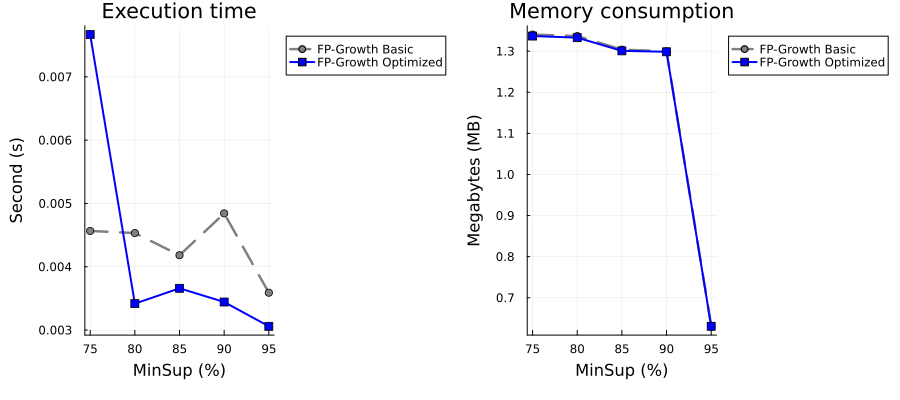

In [ ]:
results = eval_performance(CONFIG, logger, methods=[:base, :opt])
vis_performance(results, logger)


### So sánh & Đánh giá

Dựa trên biểu đồ thực nghiệm so sánh giữa **FP-Growth Basic** và **FP-Growth Optimized** trên tập dữ liệu `mushroom.dat`, chúng ta rút ra các nhận xét quan trọng sau:

#### Phân tích Thời gian thực thi (Execution Time)
- **Xu hướng chung**: Cả hai thuật toán đều hoạt động cực kỳ nhanh (dưới 0.01 giây) trên tập dữ liệu Mushroom ở các ngưỡng MinSup cao.
- **Tối ưu hóa**: Từ ngưỡng $MinSup = 80\%$ đến $95\%$, phiên bản **Optimized** luôn chạy nhanh hơn bản **Basic** (chỉ tốn khoảng `0.003s` so với `0.004s - 0.005s` của Basic, tương đương tốc độ nhanh hơn **25% - 40%**).
  - *Nguyên nhân*: Sự kết hợp giữa **Single Path Pruning** (tỉa nhánh đường đơn để không phải đệ quy sâu) và **BitArray Filtering** (tra cứu điều kiện lọc $O(1)$) đã giúp cắt giảm hàng ngàn phép tính không cần thiết khi cây FP-Tree có cấu trúc phân cấp dài.
- **Điểm bất thường ở 75%**: Ở ngưỡng MinSup thấp nhất trong thử nghiệm ($75\%$), thời gian của bản Optimized bị vọt lên `0.008s` so với `0.005s` của Basic.
  - *Nguyên nhân*: Do ở ngưỡng MinSup bắt đầu thấp, số lượng nhánh đệ quy tăng lên và thuật toán tối ưu phải chịu một phần chi phí khởi tạo (overhead) của các cấu trúc nâng cao như `BitArray` và `Lazy Buffer` cho các cây con phức tạp, trước khi phát huy tác dụng ở các cây có độ sâu lớn hơn nữa. Ngoài ra, sự can thiệp ngẫu nhiên của bộ dọn rác (Garbage Collector - GC) trong Julia cũng có thể gây nhiễu ở các lượt chạy siêu ngắn này.

#### Phân tích Mức độ tiêu thụ Bộ nhớ (Memory Consumption)
- **Sự trùng khớp hoàn hảo**: Đường biểu đồ bộ nhớ của cả hai phiên bản gần như trùng khít hoàn toàn (ở mức `1.34 MB` và giảm mạnh xuống `0.63 MB` tại ngưỡng $95\%$).
- **Phân tích nguyên nhân**:
  1. **Số lượng tập phổ biến quá nhỏ**: Ở các ngưỡng MinSup cực cao này ($75\% - 95\%$), số lượng tập phổ biến sinh ra chỉ dao động từ **7 đến 31 tập**.
  2. **Chi phí nền**: Với kích thước dữ liệu và số lượng tập phổ biến nhỏ như vậy, lượng RAM cấp phát để đệ quy xây dựng FP-Tree là không đáng kể. Phần lớn lượng RAM tiêu thụ (1.3 MB) thực chất là chi phí cố định để nạp tập dữ liệu Mushroom vào cấu trúc Vector giao dịch của Julia. Do đó, hai đường đồ thị đè lên nhau hoàn toàn.